#YOLOV8


In [ ]:
pwd

'/content'

In [ ]:
!nvidia-smi

Mon Apr 22 06:40:34 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   33C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
# Pip install method (recommended)

!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 29.1/78.2 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

/content
100% 6.23M/6.23M [00:00<00:00, 81.0MB/s]
Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs

100% 104k/104k [00:00<00:00, 46.9MB/s]
WARNING ⚠️ NMS time limit 0.550s exceeded
image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 125.4ms
Speed: 13.7ms preprocess, 125.4ms inference, 1193.4ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


yolo mode=predict runs YOLOv8 inference on a variety of sources, downloading models automatically from the latest YOLOv8 release, and saving results to runs/predict.


/content


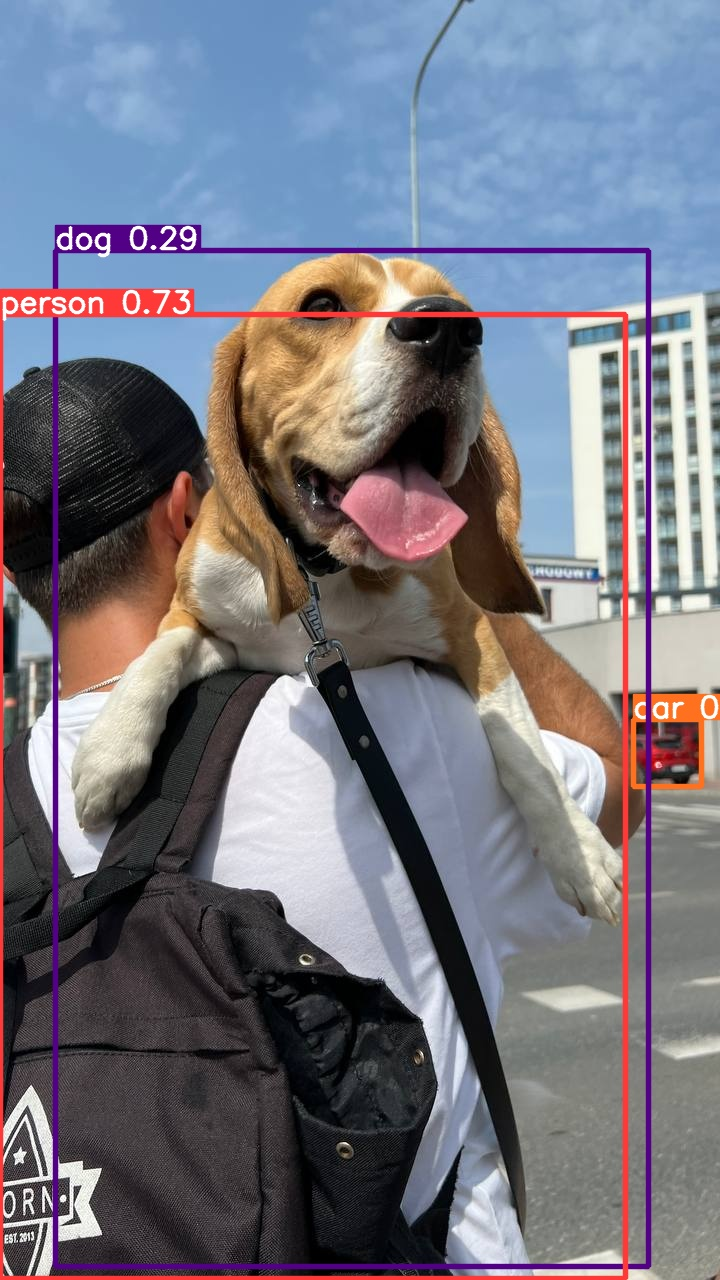

In [ ]:
%cd {HOME}
Image(filename='runs/detect/predict/dog.jpeg', height=600)

In [ ]:
%cd {HOME}
#this leads to prexdiction from model and sves in runs/detect/predict{num}
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='/content/VED edit.jpg'

/content
Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/VED edit.jpg: 448x640 7 persons, 127.5ms
Speed: 4.2ms preprocess, 127.5ms inference, 543.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


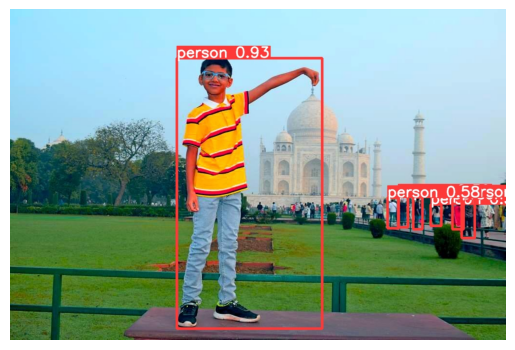

In [ ]:
import cv2
from matplotlib import pyplot as plt

# Read the image
img = cv2.imread(r"/content/runs/detect/predict2/VED edit.jpg")
#imshow doesnt work
# Convert the image from BGR to RGB (matplotlib uses RGB)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_rgb)
plt.axis('off')  # Turn off axis numbers and ticks
plt.show()
#or simply
# Image(filename="/content/runs/detect/predict2/VED edit.jpg", height=600)

In [ ]:
model = YOLO(f'{HOME}/yolov8n.pt')
results = model.predict(source='https://media.roboflow.com/notebooks/examples/dog.jpeg', conf=0.25)


Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg
WARNING ⚠️ NMS time limit 0.550s exceeded
image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 234.4ms
Speed: 16.6ms preprocess, 234.4ms inference, 1147.6ms postprocess per image at shape (1, 3, 640, 384)


In [ ]:
results[0].boxes.xyxy

tensor([[   0.0000,  314.4717,  625.0754, 1278.1946],
        [  55.1731,  250.0220,  648.1080, 1266.2720],
        [ 633.2291,  719.5391,  701.0538,  786.0336]], device='cuda:0')

In [ ]:
print(results[0].boxes.conf,
results[0].boxes.cls)

tensor([0.7271, 0.2907, 0.2846], device='cuda:0') tensor([ 0., 16.,  2.], device='cuda:0')


Loading the dataset

In [ ]:
pwd

'/content'

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nVqVokqcZw56QzufoOOo")
project = rf.workspace("anant-yu2b9").project("myproject-sea25")
version = project.version(3)
dataset = version.download("yolov8")


#dataset has train,test,validate folders and each folder has images and label.txt files

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to myproject-3 in yolov8:: 100%|██████████| 1644/1644 [00:00<00:00, 5066.68it/s]


#Training of custom Model


In [ ]:
pwd

'/content'

What is the difference between DFL loss and box loss?
The box loss corresponds to how well the model is able to locate the object within the bounding box. The DFL loss is used to handle class imbalance in the object detection process. Meanwhile, the classification loss is responsible for ensuring that the detected objects are correctly classified.

25 epoch ,yolo8 small model,data.yaml are specified


In [ ]:


!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=35 imgsz=800 plots=True

New https://pypi.org/project/ultralytics/8.2.2 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/myproject-3/data.yaml, epochs=35, patience=50, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, stream_buffer=False, line_width=None, visualize=False, augment=False, 

In [ ]:
!ls {HOME}/runs/detect/train3/

args.yaml					     R_curve.png	  val_batch0_labels.jpg
confusion_matrix_normalized.png			     results.csv	  val_batch0_pred.jpg
confusion_matrix.png				     results.png	  val_batch1_labels.jpg
events.out.tfevents.1713772568.0675d5ccfac1.20272.0  train_batch0.jpg	  val_batch1_pred.jpg
F1_curve.png					     train_batch1100.jpg  val_batch2_labels.jpg
labels_correlogram.jpg				     train_batch1101.jpg  val_batch2_pred.jpg
labels.jpg					     train_batch1102.jpg  weights
P_curve.png					     train_batch1.jpg
PR_curve.png					     train_batch2.jpg


/content


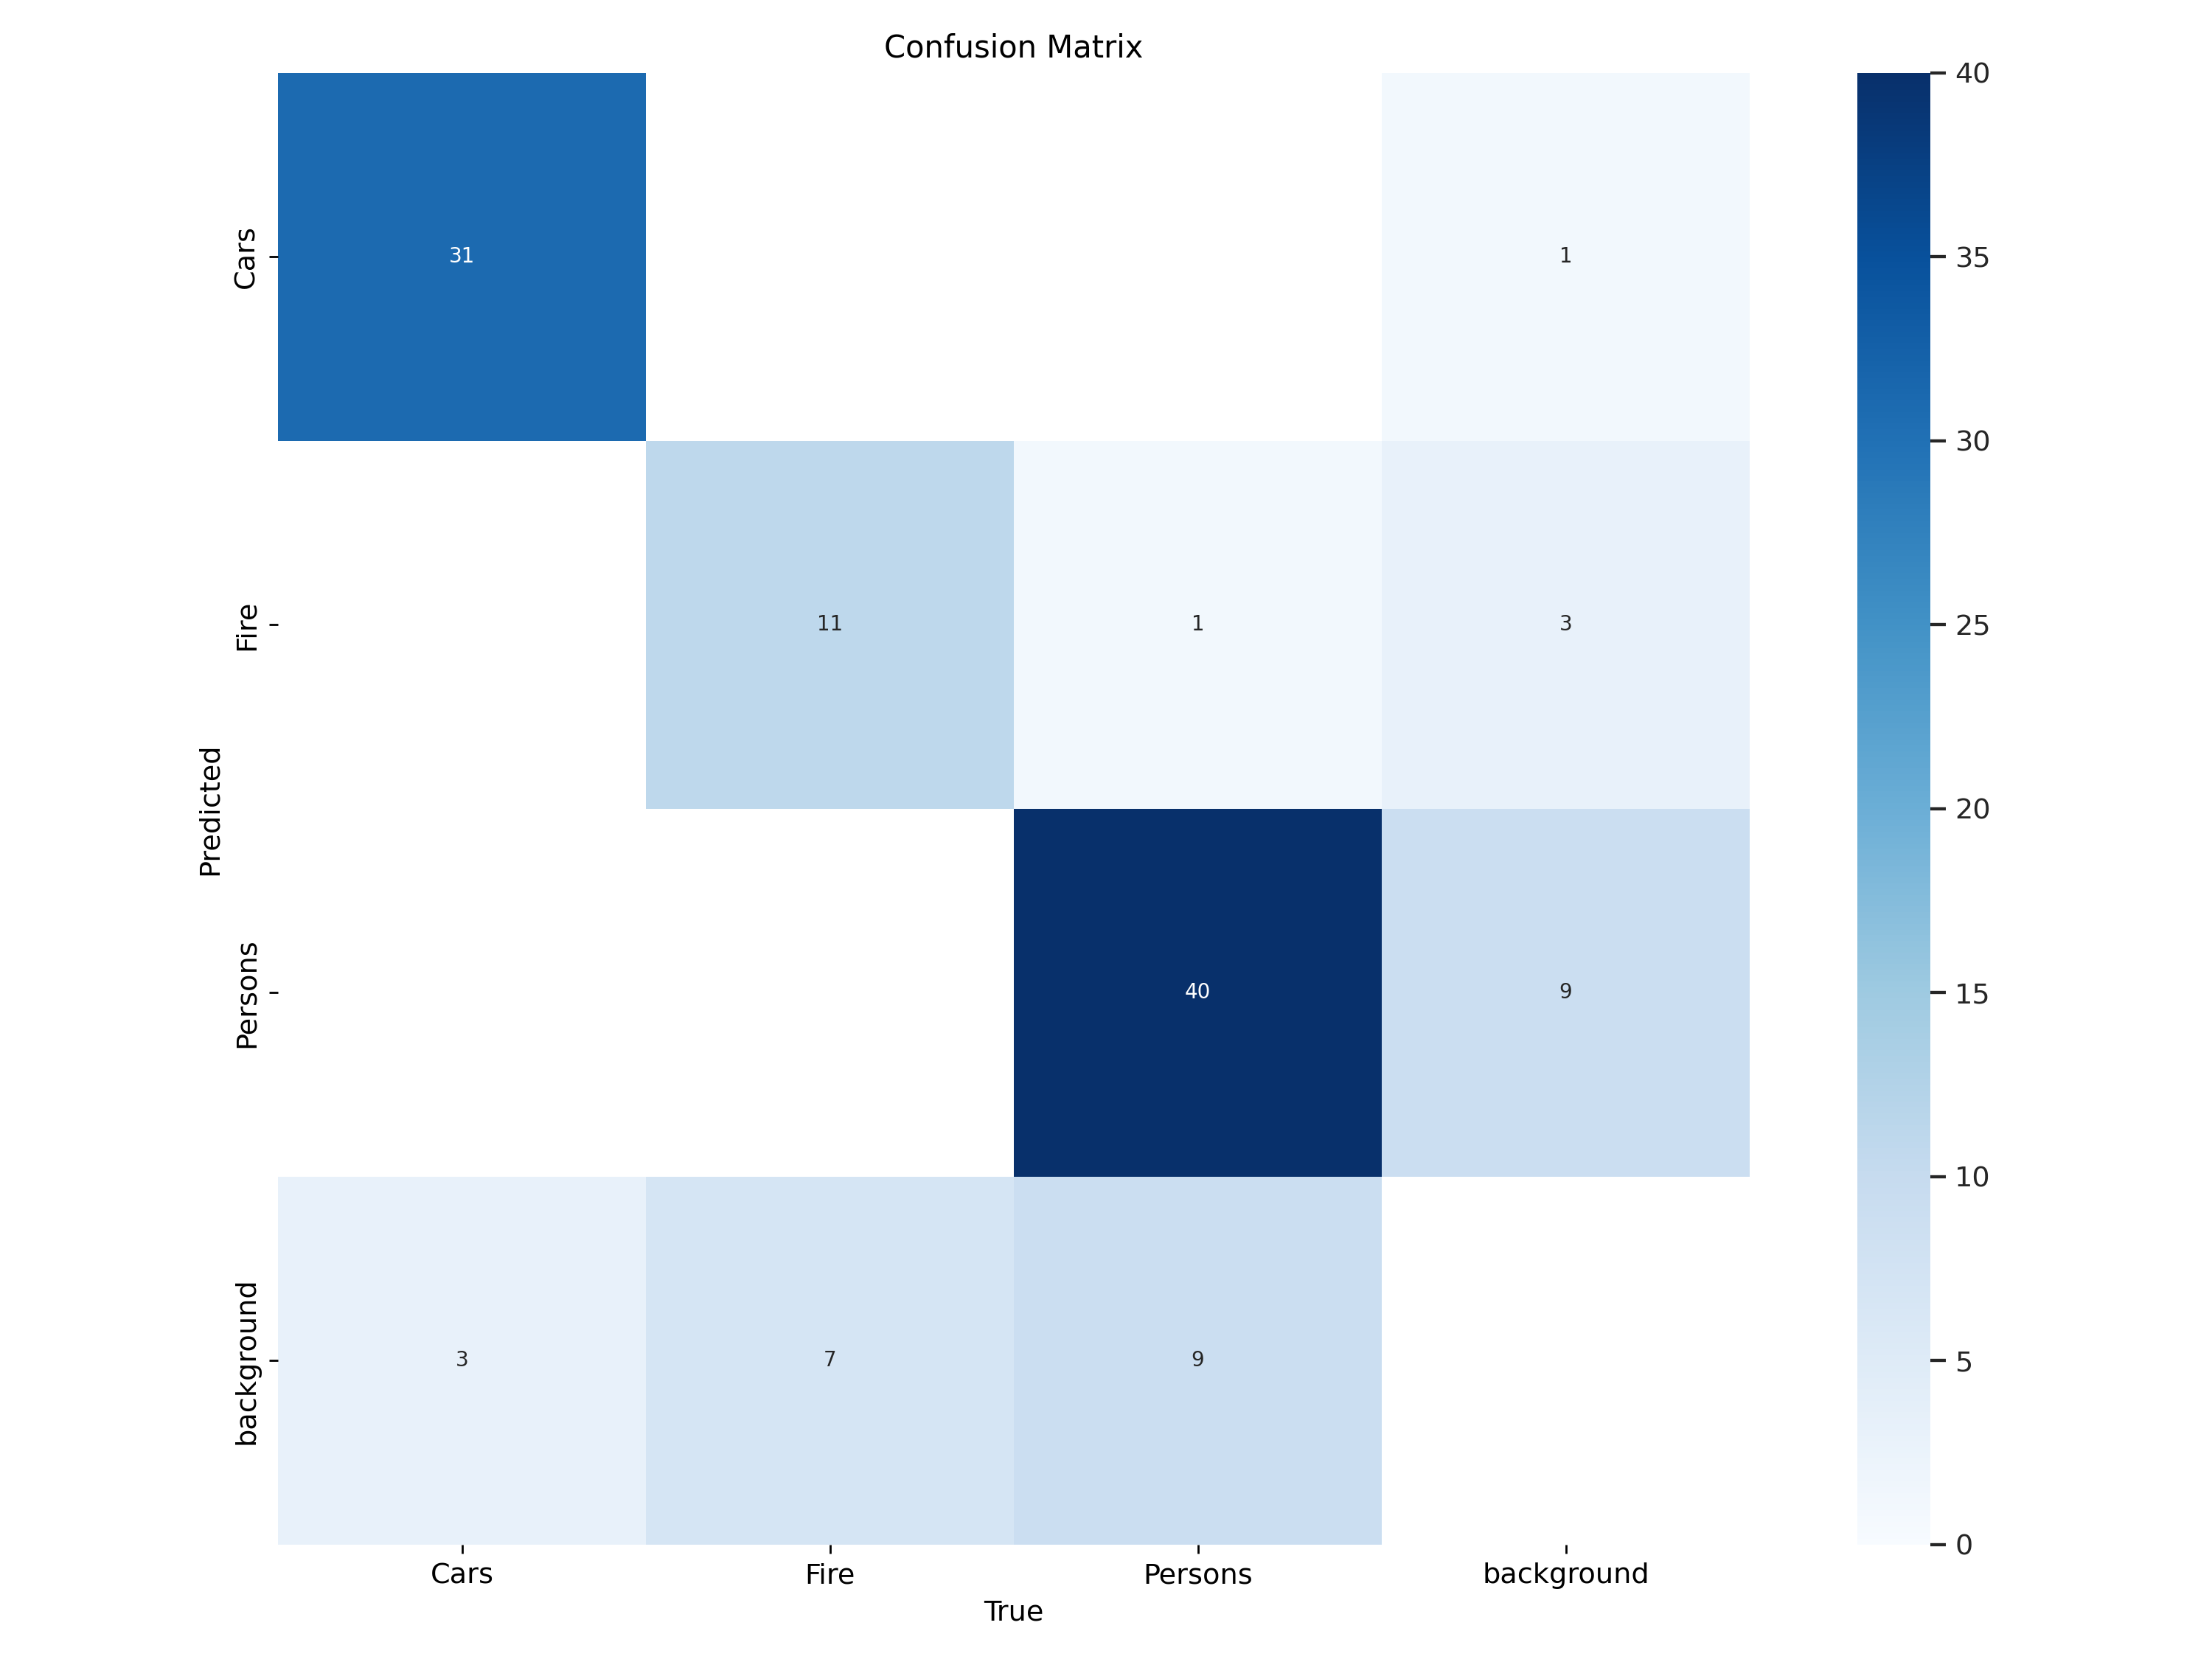

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train3/confusion_matrix.png', width=600)

/content


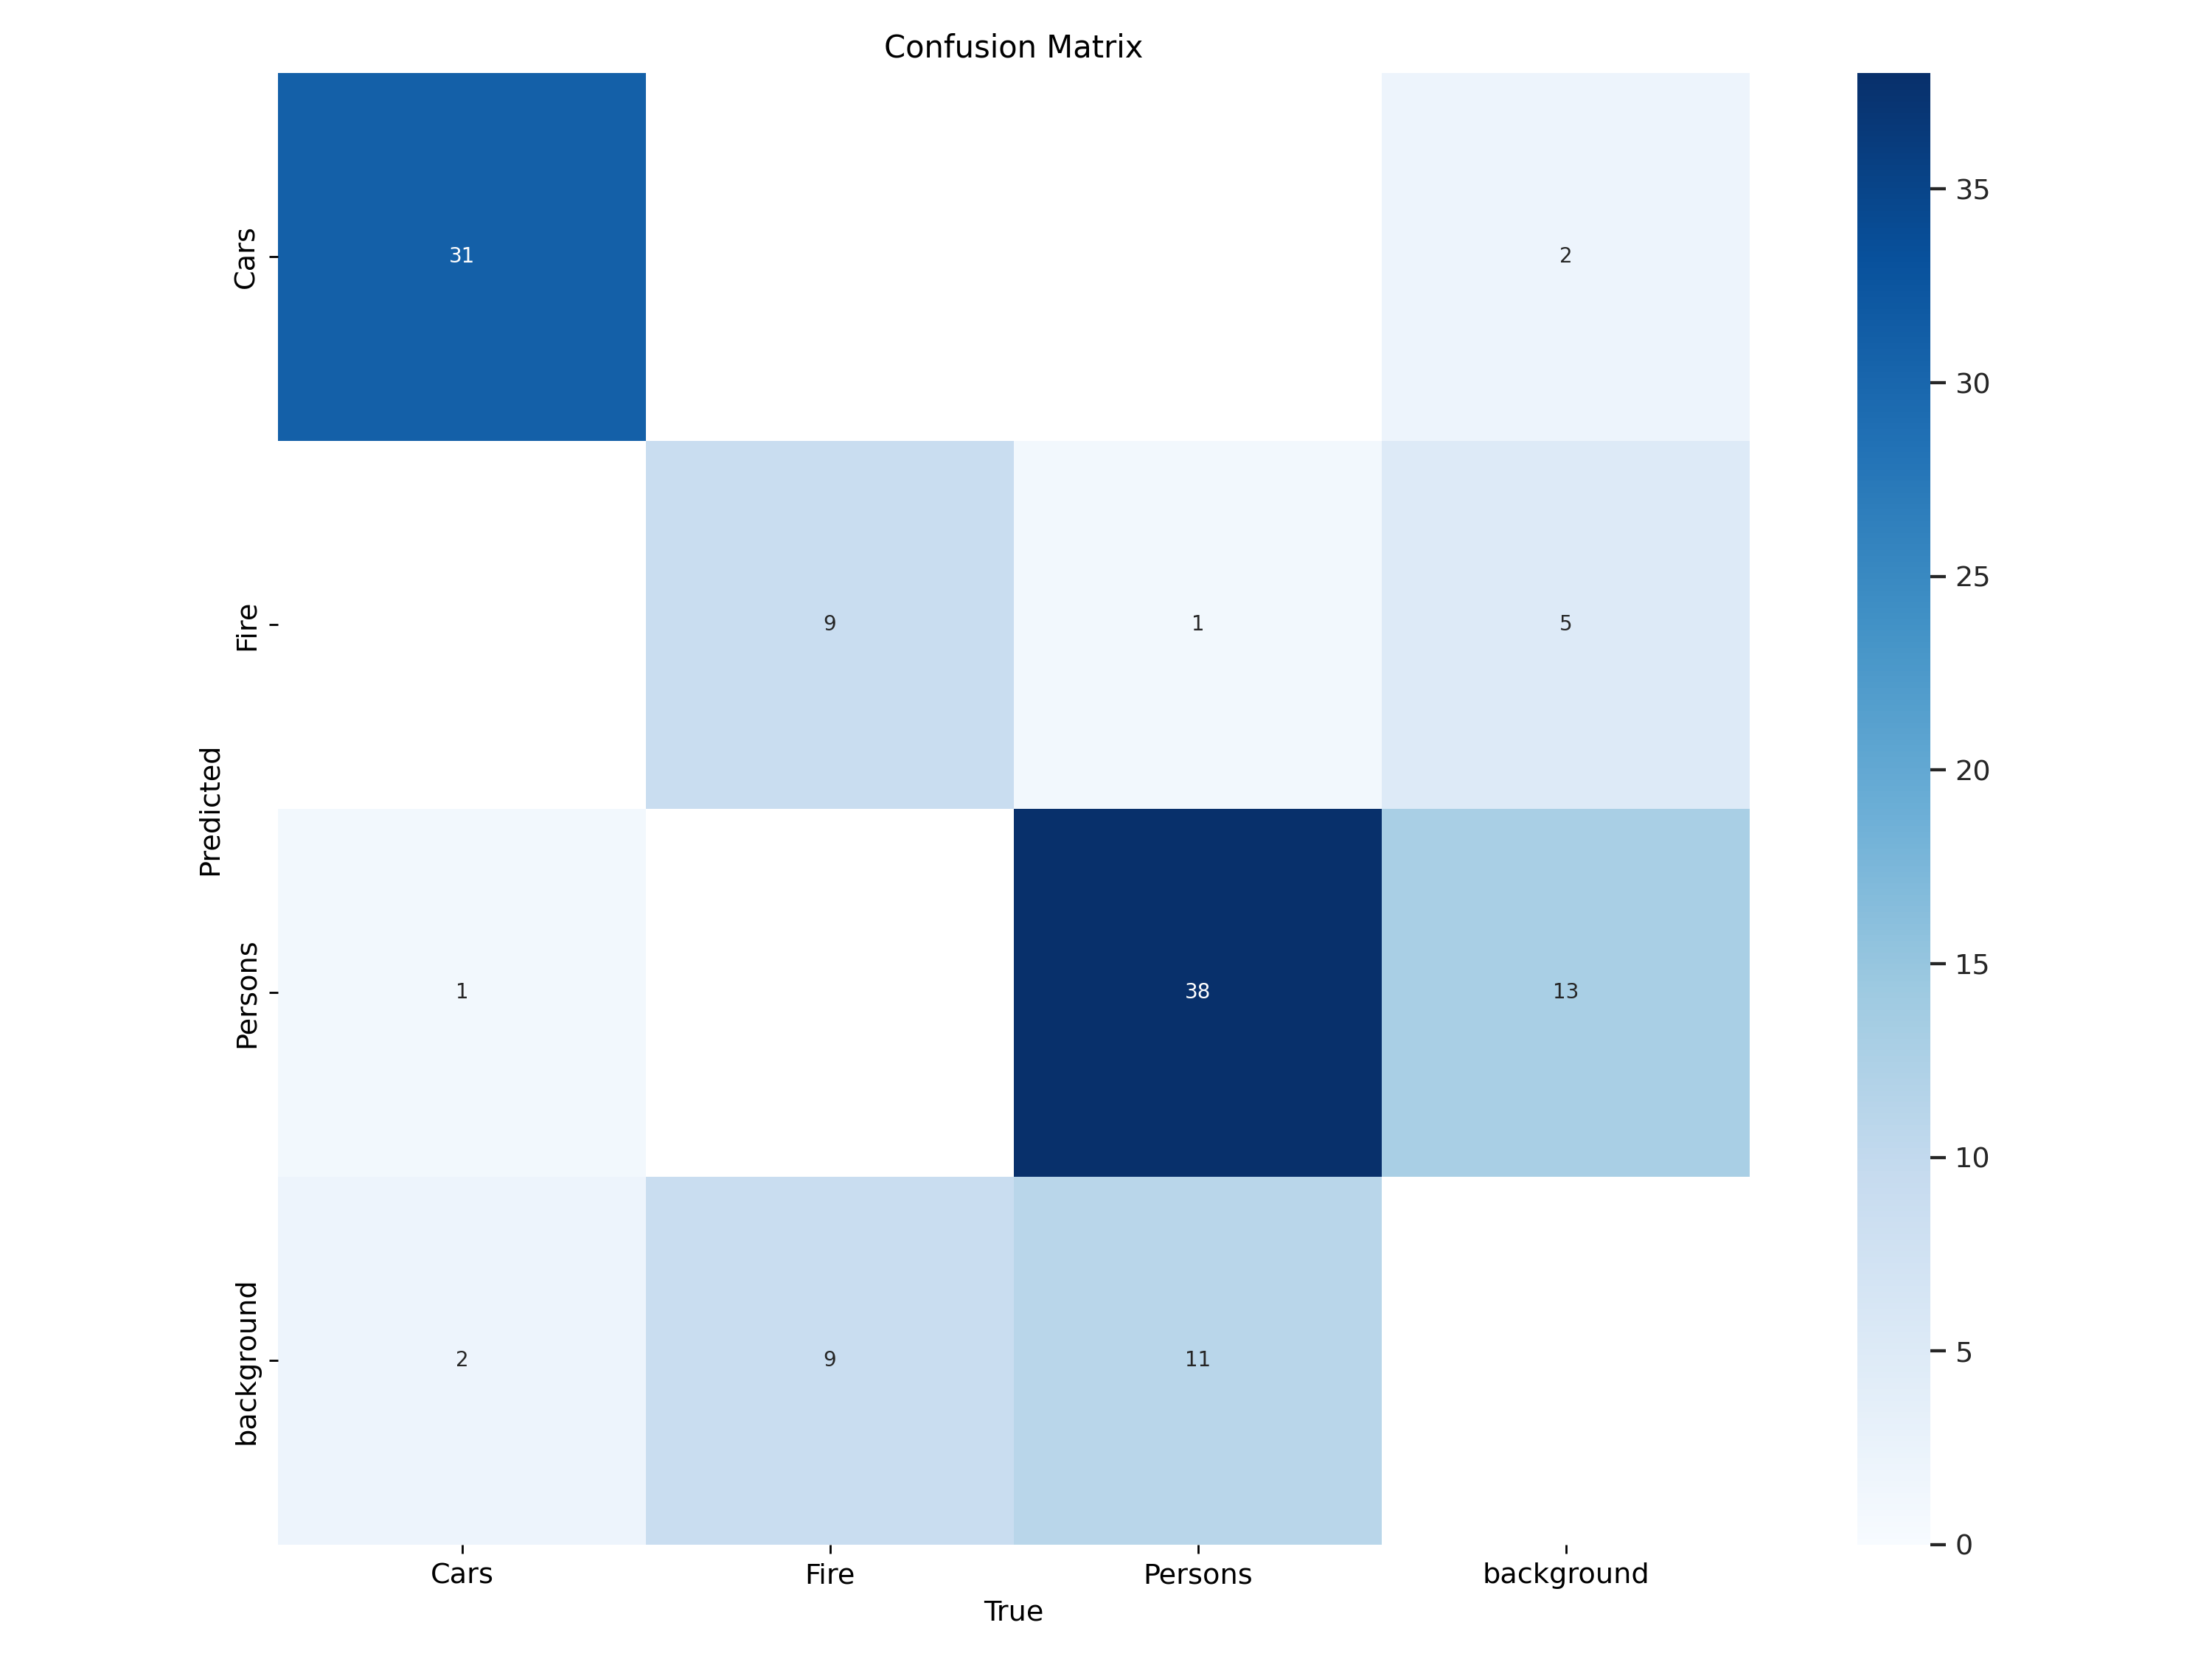

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=600)

/content


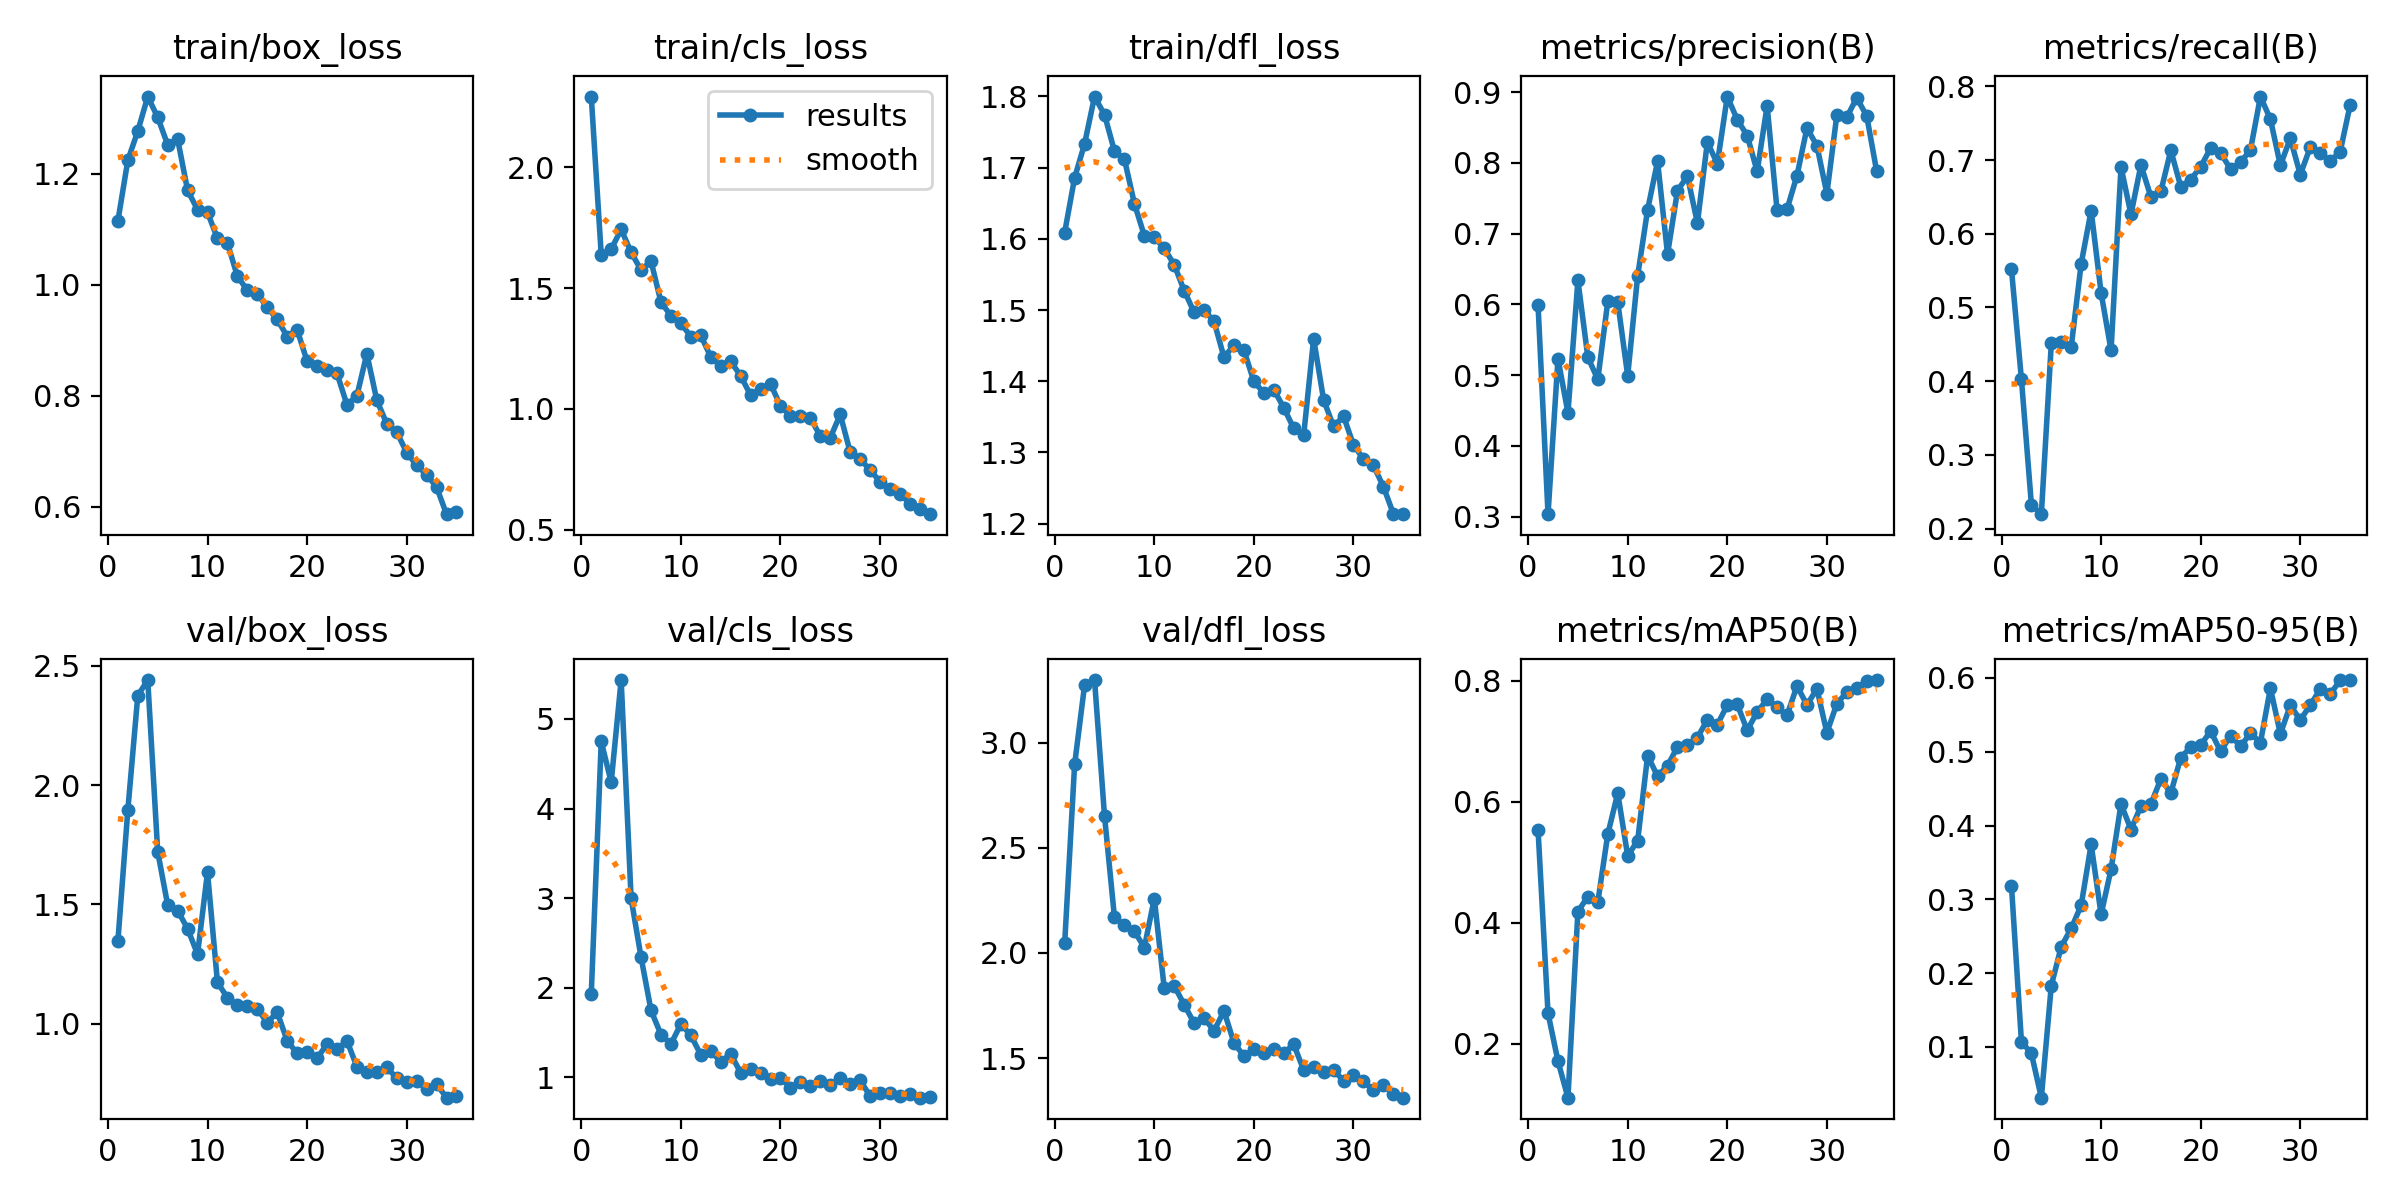

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train3/results.png', width=600)

/content


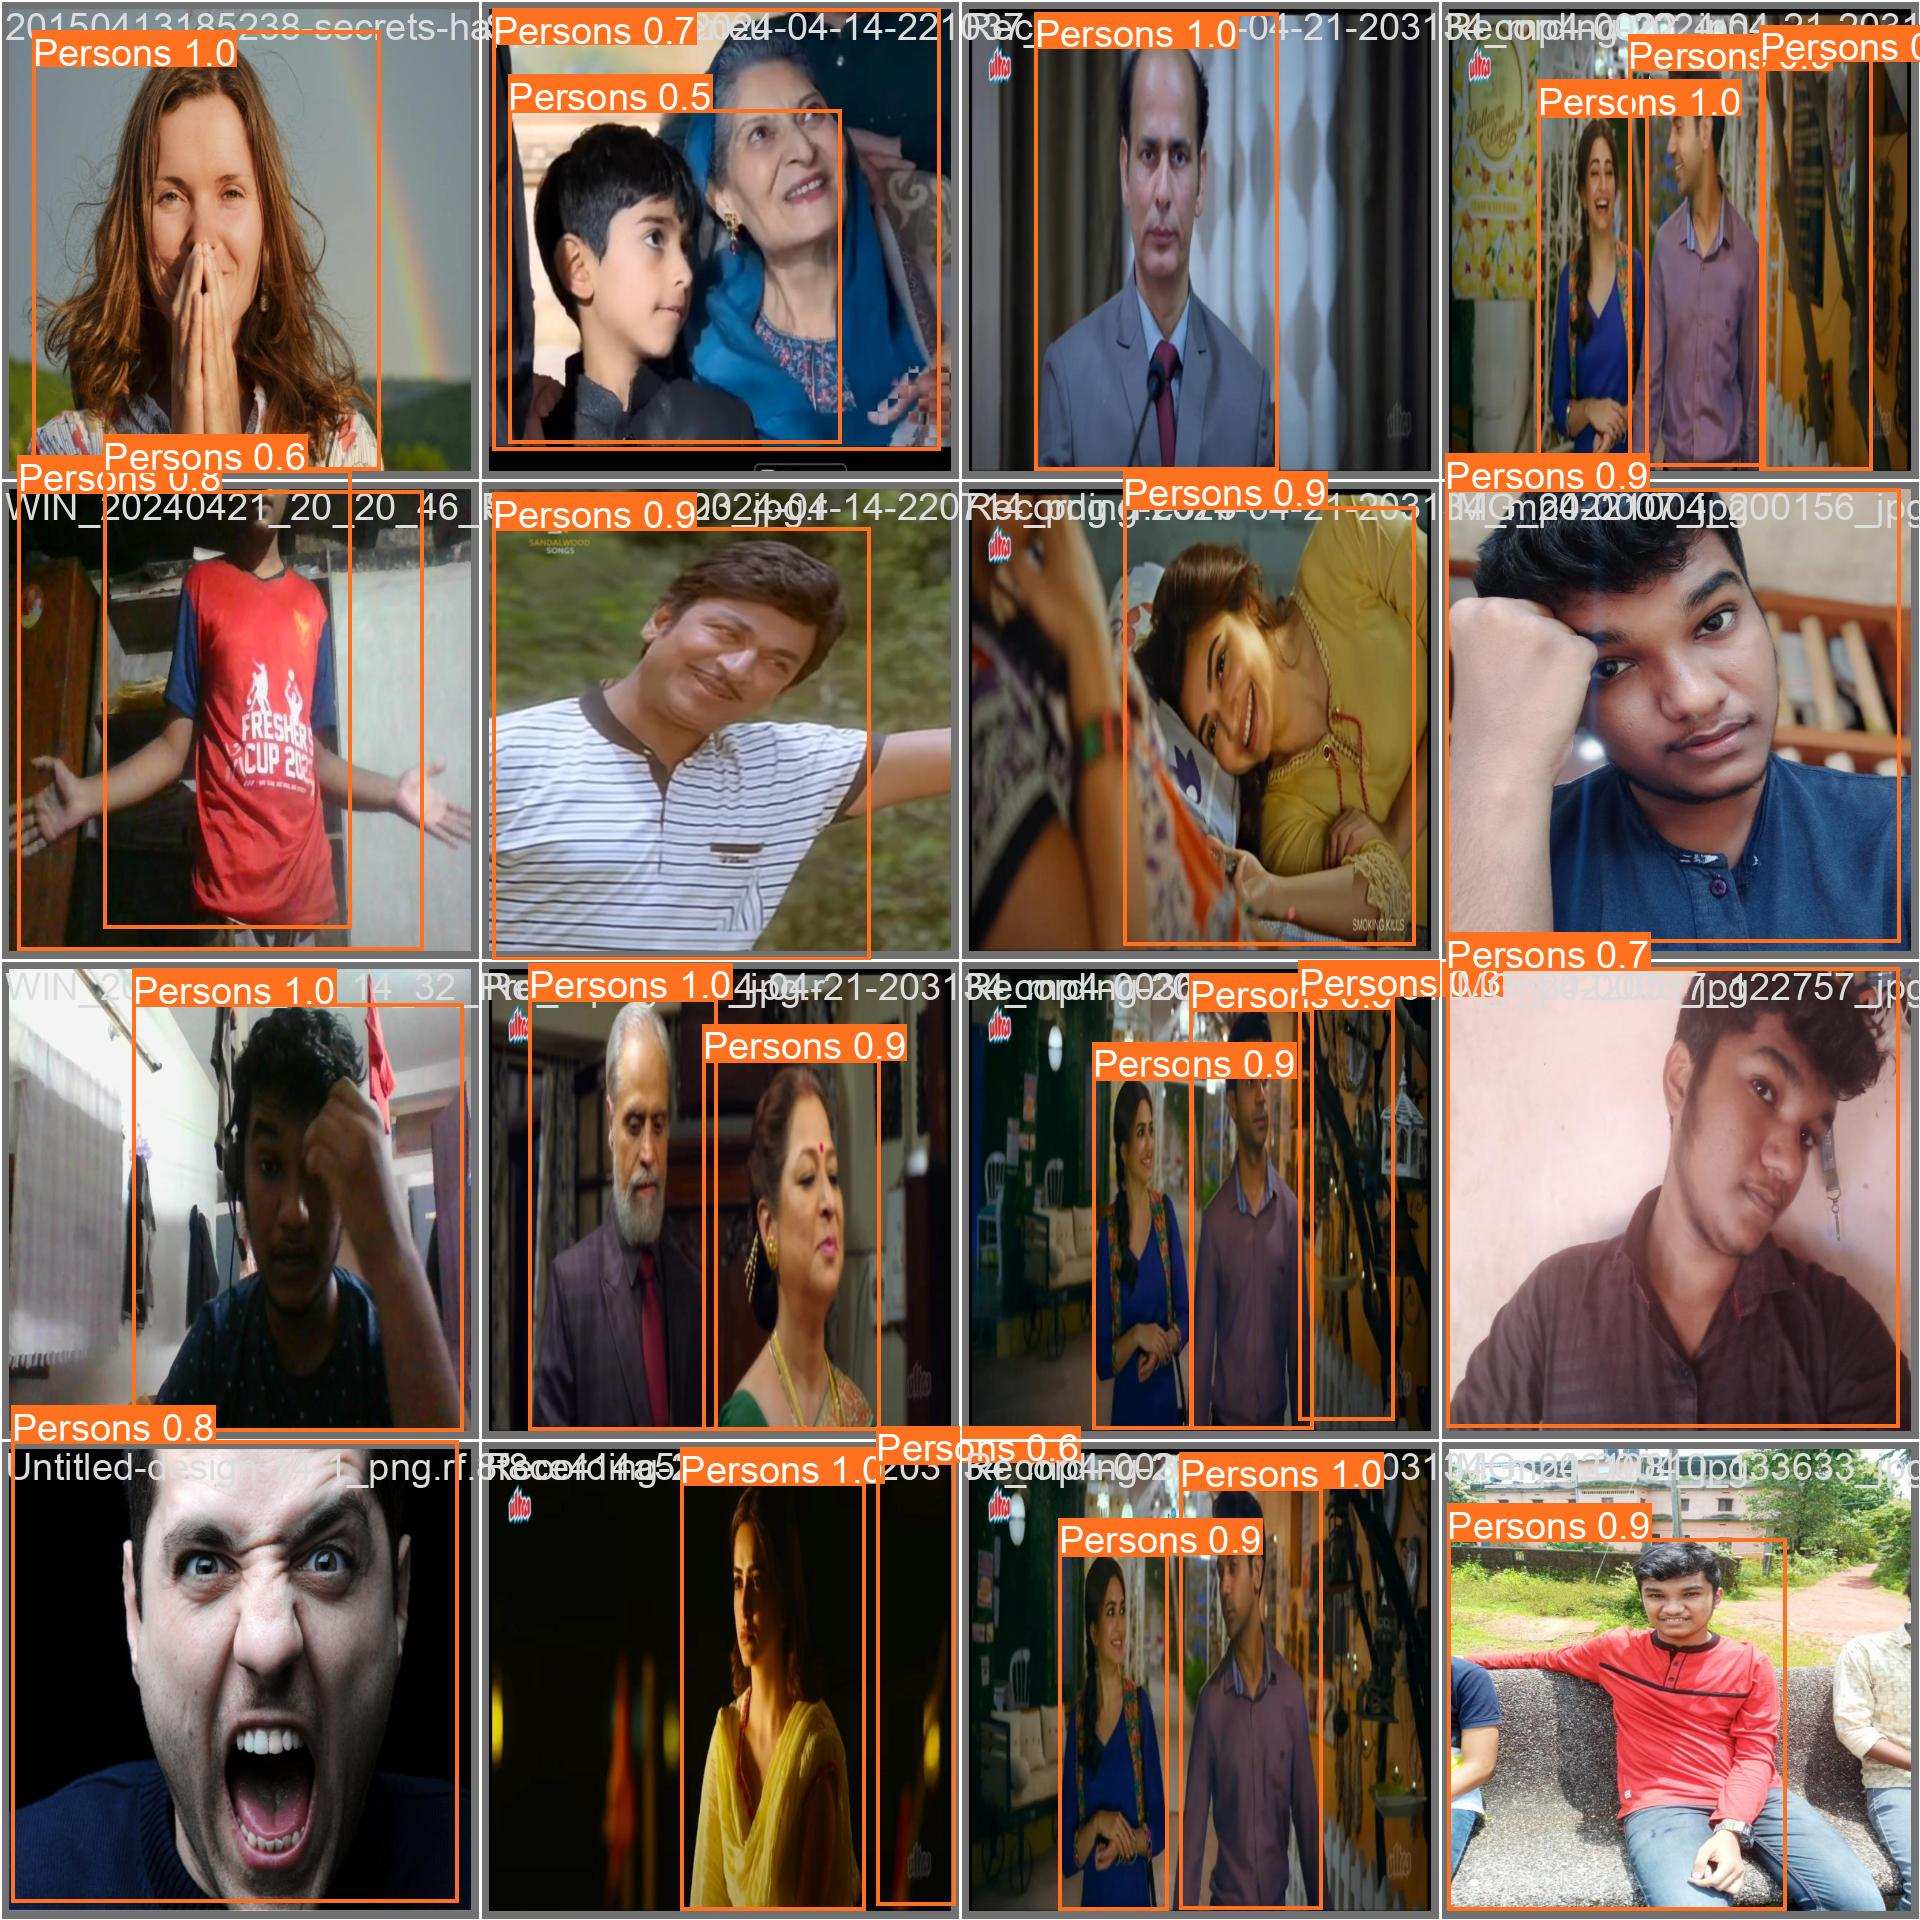

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train3/val_batch0_pred.jpg', width=600)


/content


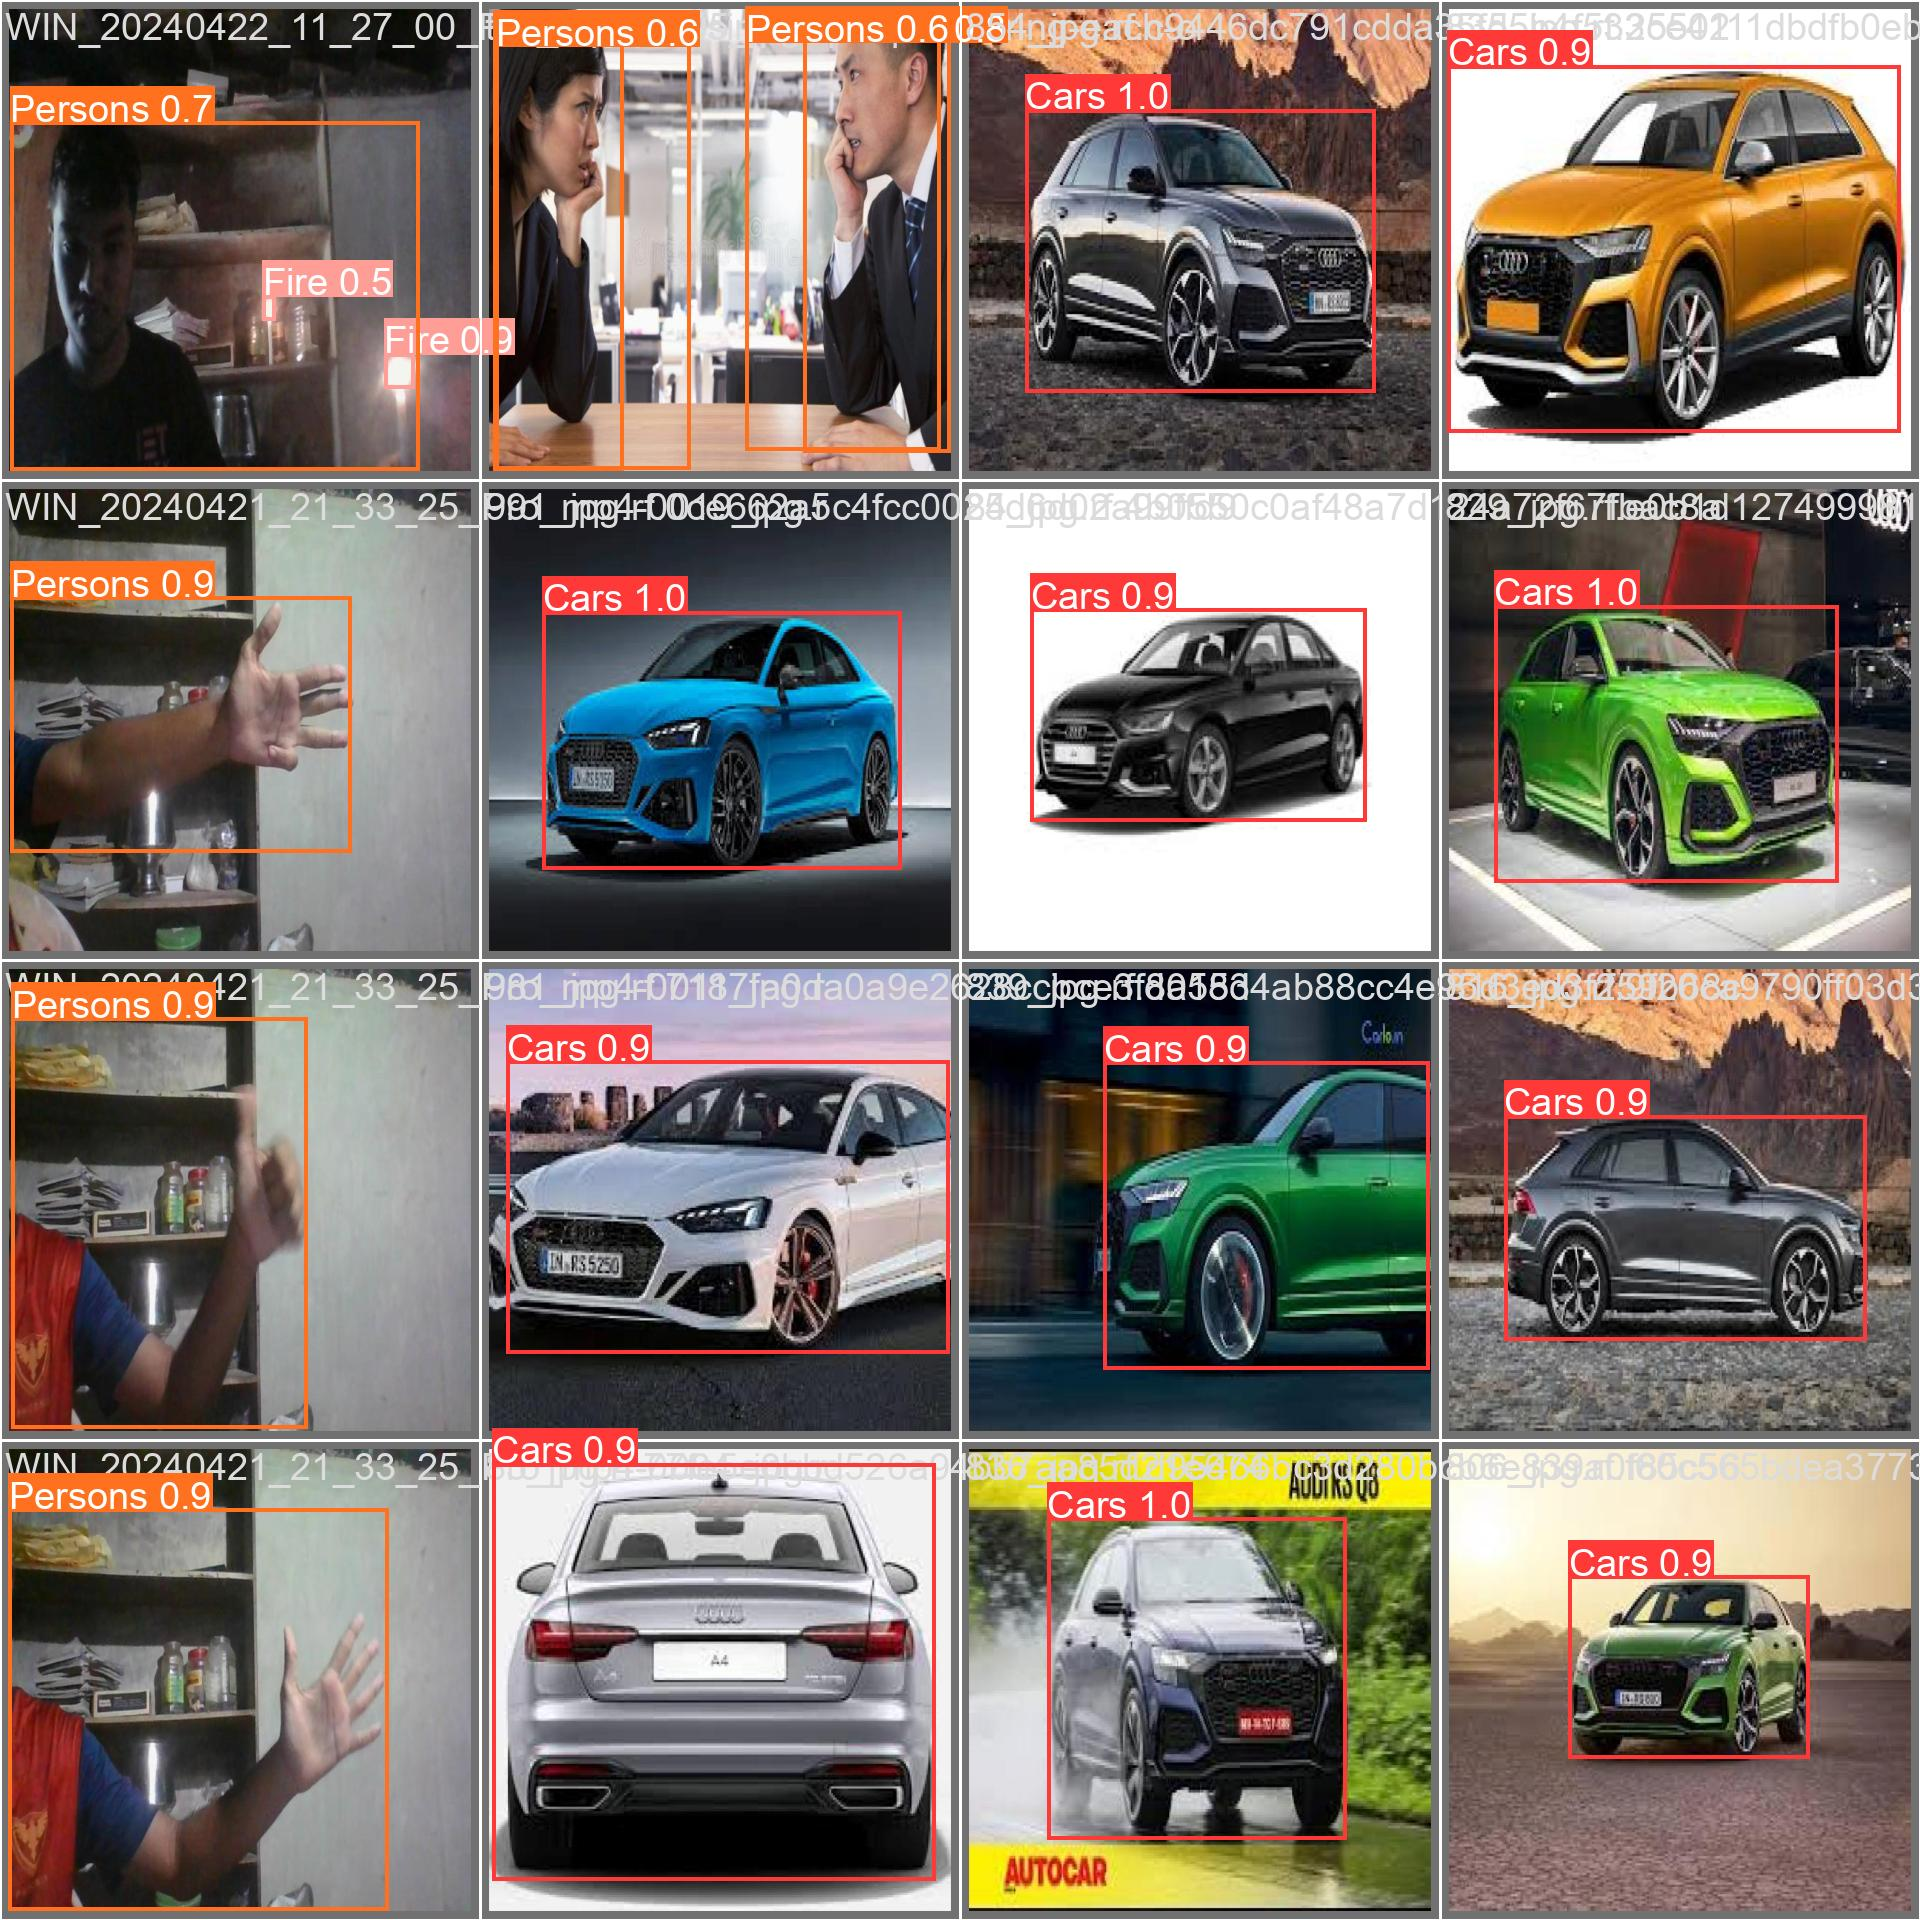

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train3/val_batch1_pred.jpg', width=600)

VALIDATING CUSTOM MODEL

In [ ]:

!yolo task=detect mode=val model={HOME}/runs/detect/train3/weights/best.pt data={dataset.location}/data.yaml

Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11126745 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/myproject-3/valid/labels.cache... 75 images, 0 backgrounds, 0 corrupt: 100% 75/75 [00:00<?, ?it/s]
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 5/5 [00:04<00:00,  1.09it/s]
                   all         75        102      0.789      0.774      0.801      0.598
                  Cars         75         34      0.917      0.912      0.932      0.876
                  Fire         75         18      0.707      0.611      0.636      0.312
               Persons         75         50      0.741        0.8      0.833      0.6

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train3/weights/best.pt conf=0.250 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11126745 parameters, 0 gradients, 28.4 GFLOPs

image 1/38 /content/myproject-3/test/images/109_jpg.rf.91f74fc07928f2c5c9d27afc08726d29.jpg: 800x800 2 Fires, 22.5ms
image 2/38 /content/myproject-3/test/images/12_jpg.rf.242ad49c53452de7e975072c4661d718.jpg: 800x800 1 Fire, 22.5ms
image 3/38 /content/myproject-3/test/images/170404-happy-workers-feature_jpg.rf.d65b97d1eb6d45bb1d5a244316c44965.jpg: 800x800 10 Personss, 22.5ms
image 4/38 /content/myproject-3/test/images/1O2A3334_JPG.rf.e5fd0638328ddef83f8545bd67643fb0.jpg: 800x800 2 Personss, 22.4ms
image 5/38 /content/myproject-3/test/images/812_jpg.rf.a7f252bb20d58ed696f446cd222dc03c.jpg: 800x800 1 Cars, 22.5ms
image 6/38 /content/myproject-3/test/images/817_jpg.rf.b81f346afb83fb26f94a67be5b53e2ed.jpg: 800x800 1 Cars, 21.3ms
image 7/38 /content/myproject-3/test/images/838_jpg.rf.4b93de36117681f929226dea05d3cde

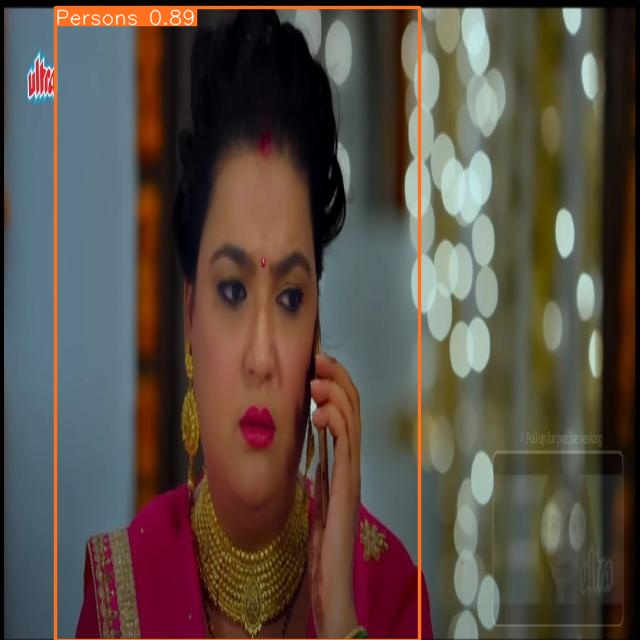

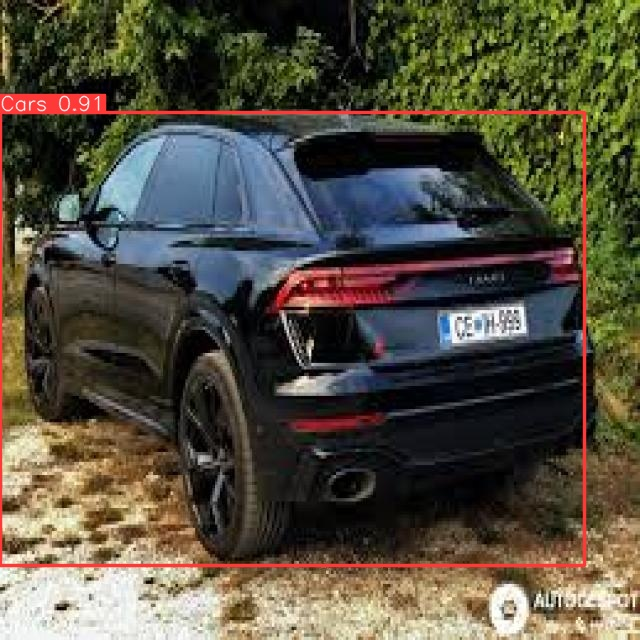

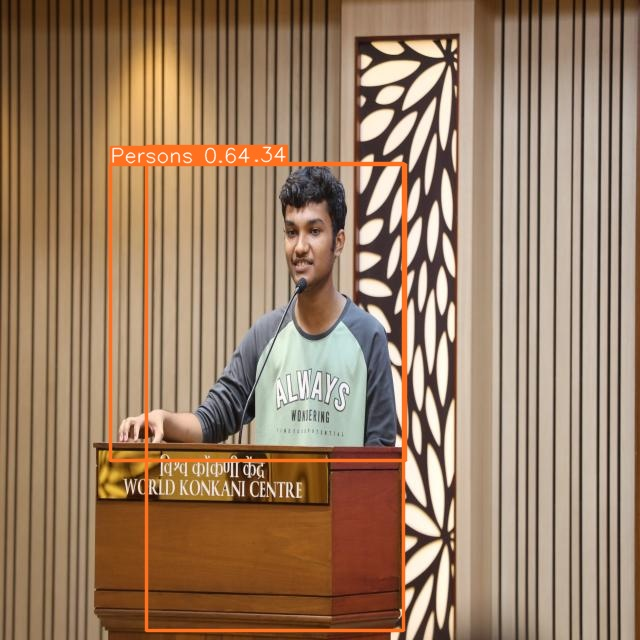

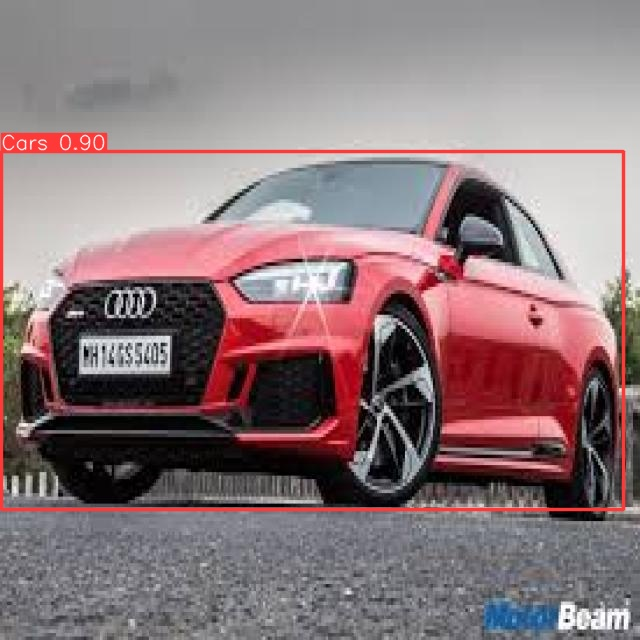

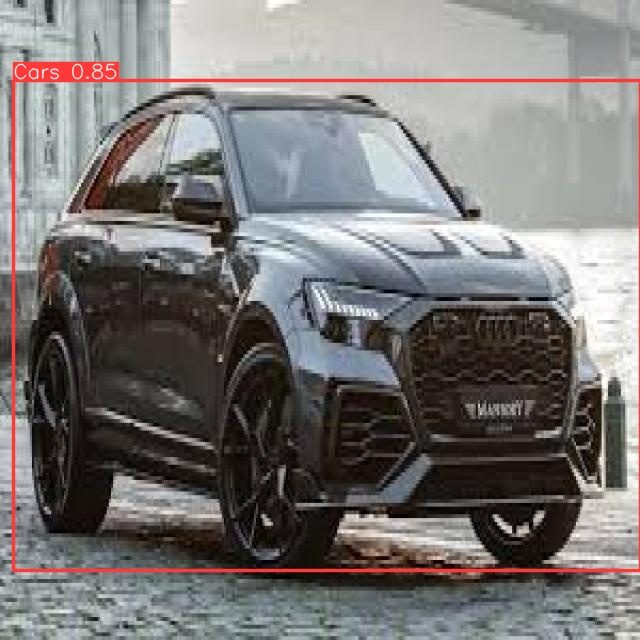

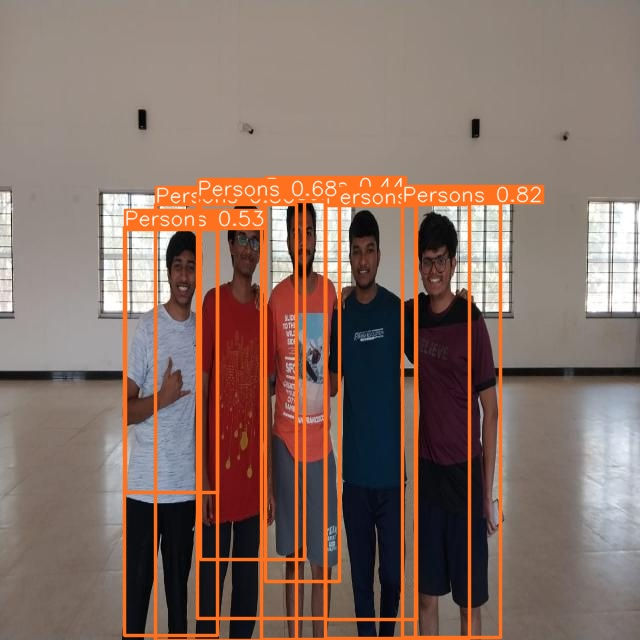

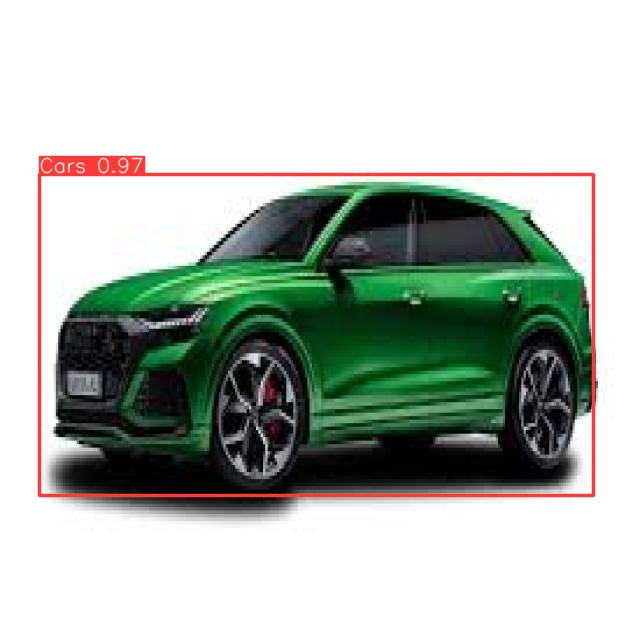

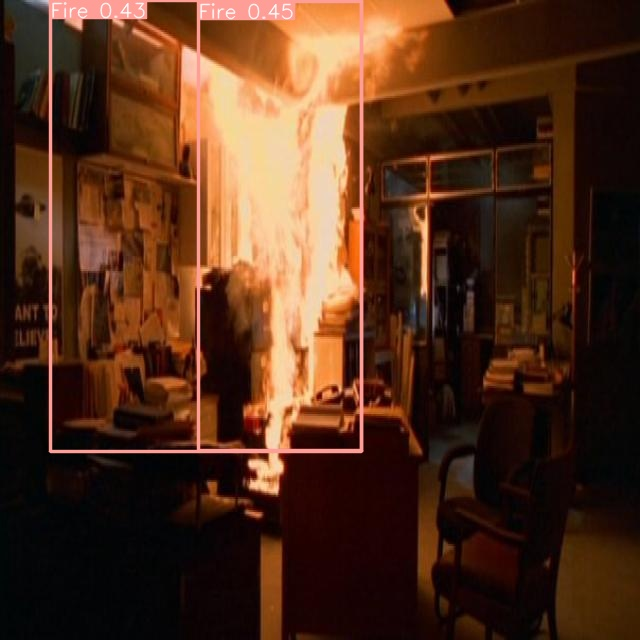

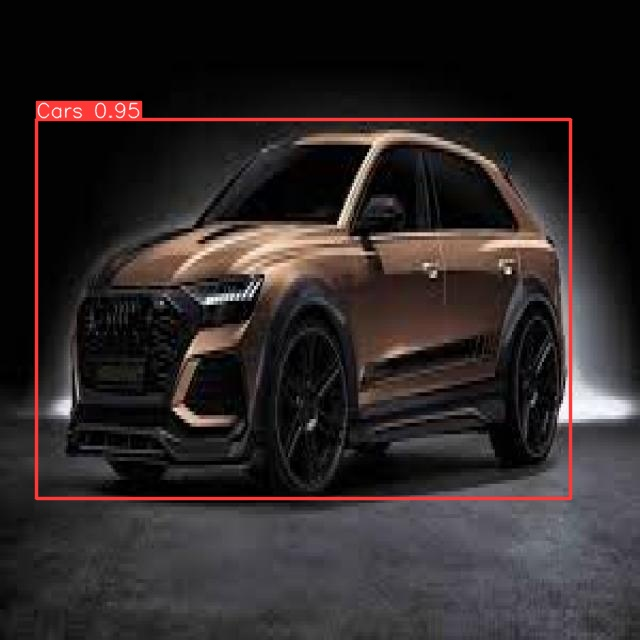

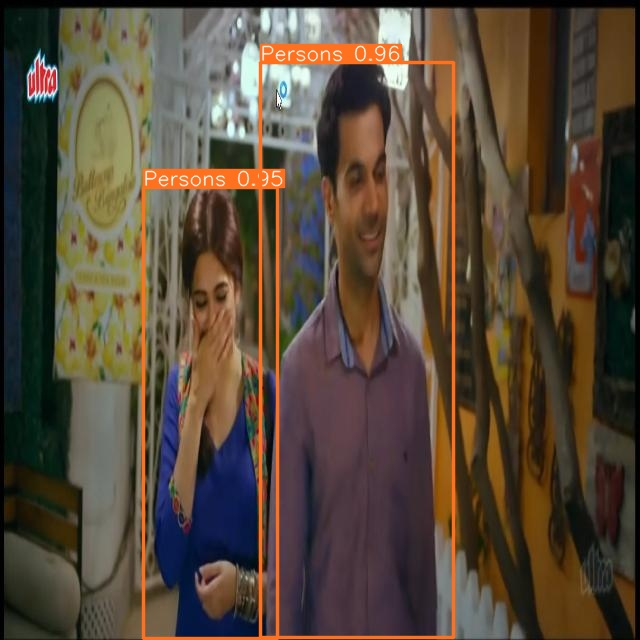

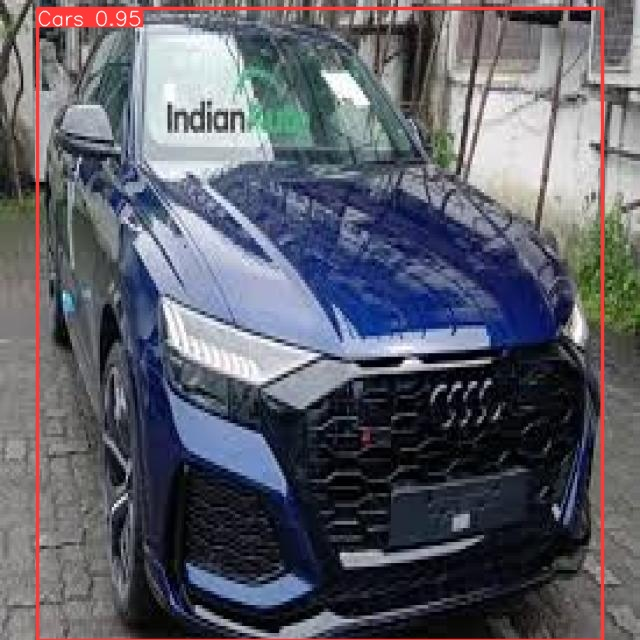

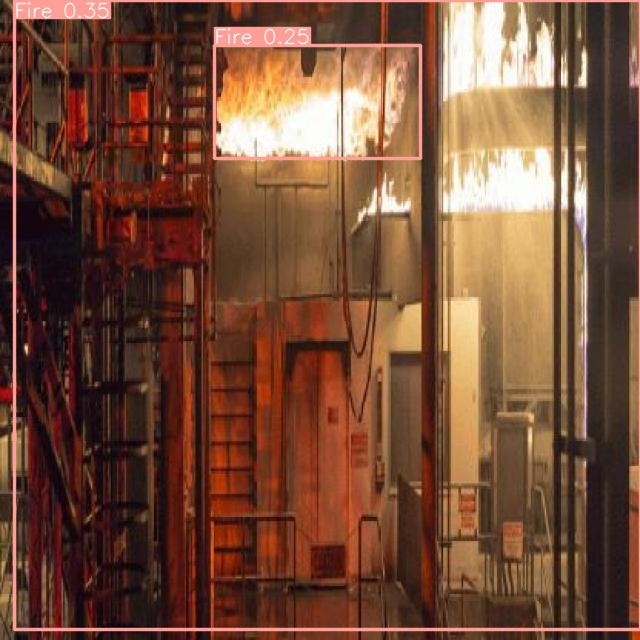

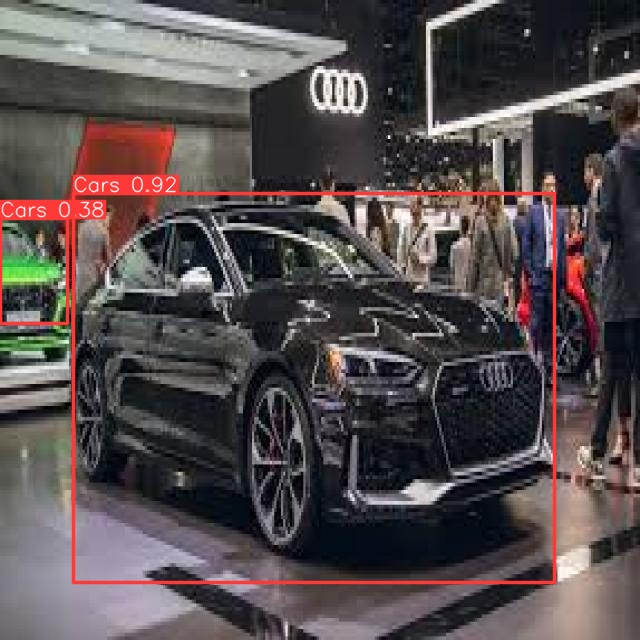

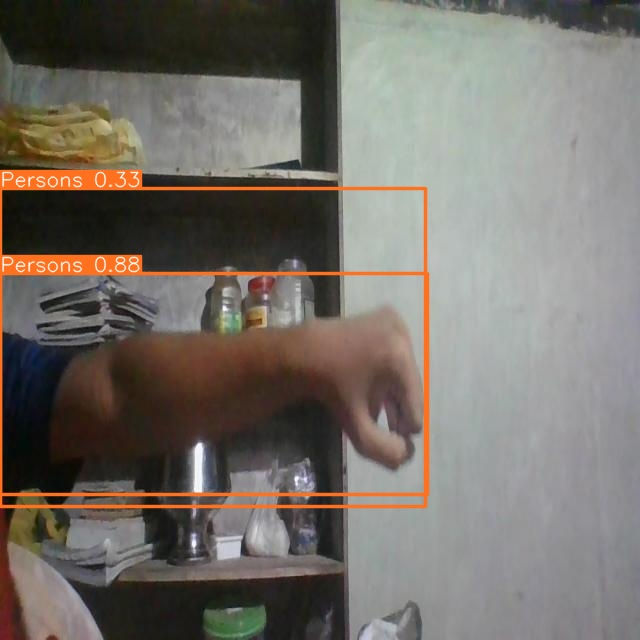

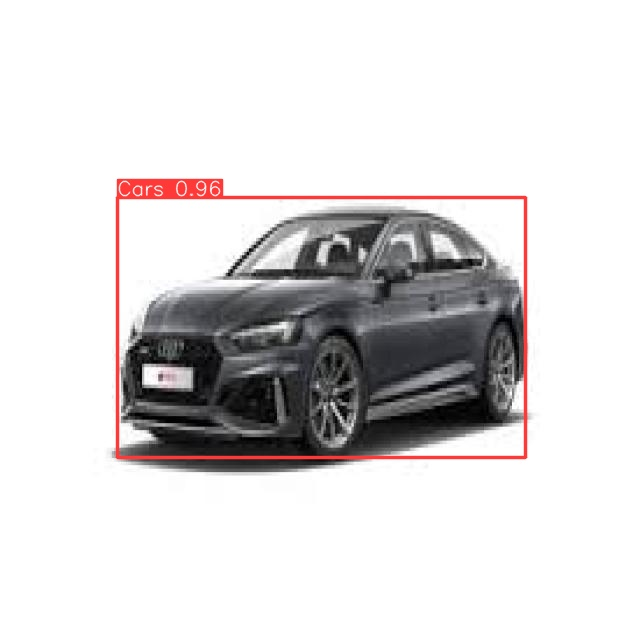

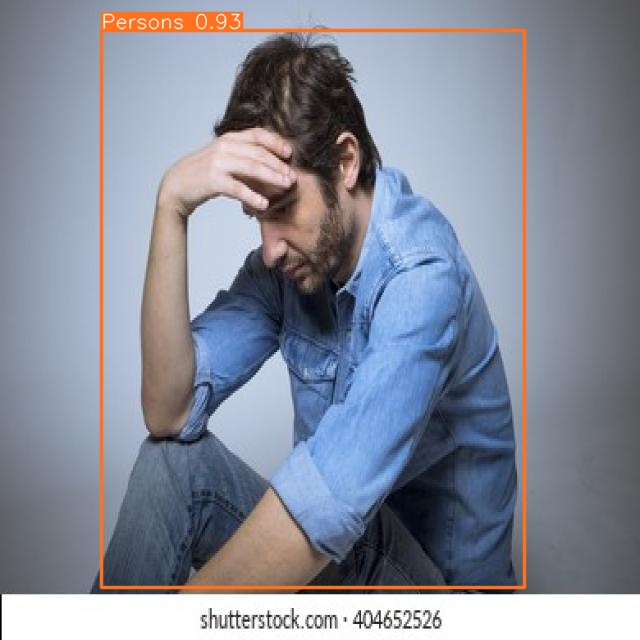

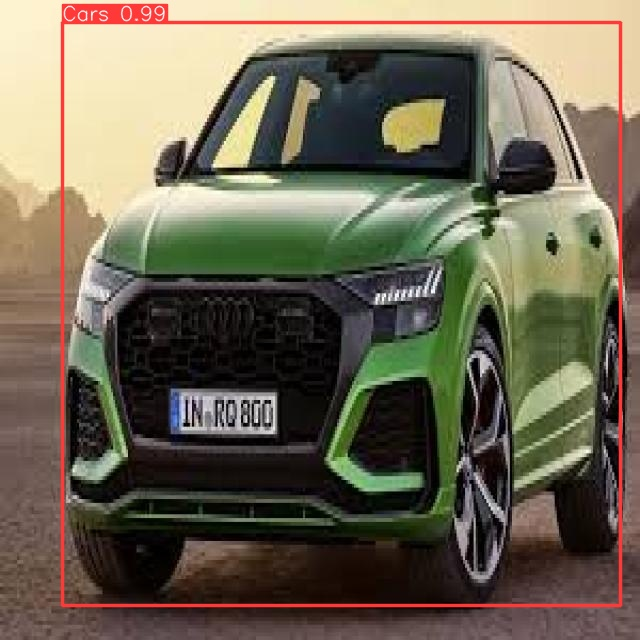

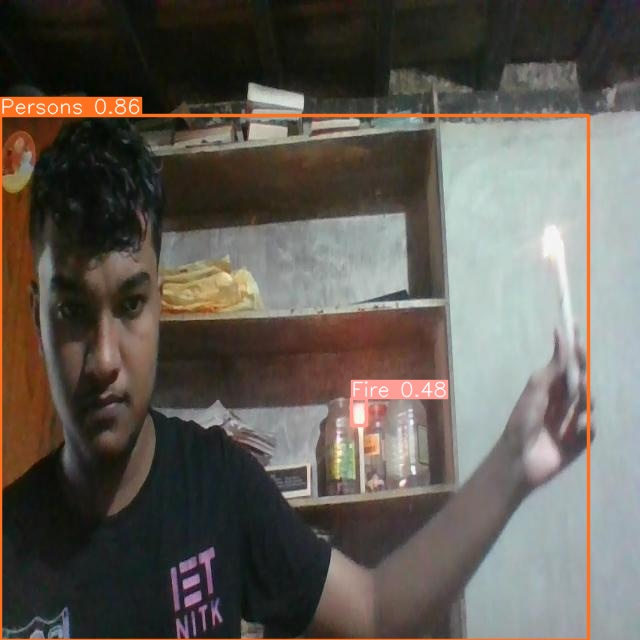

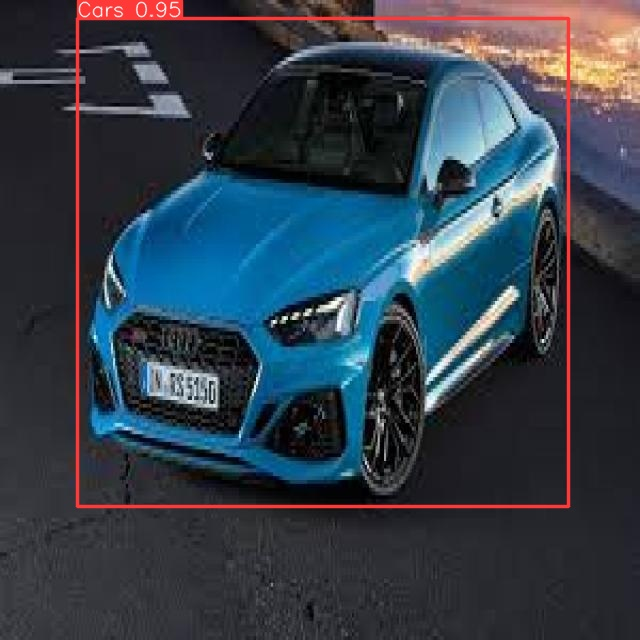

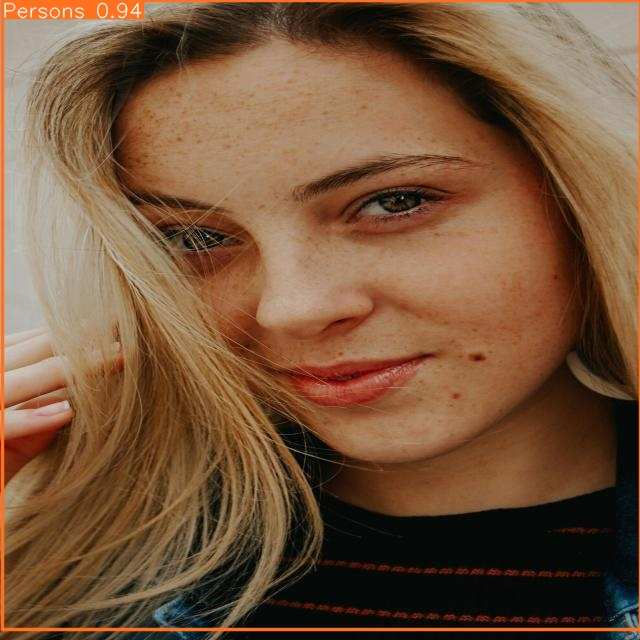

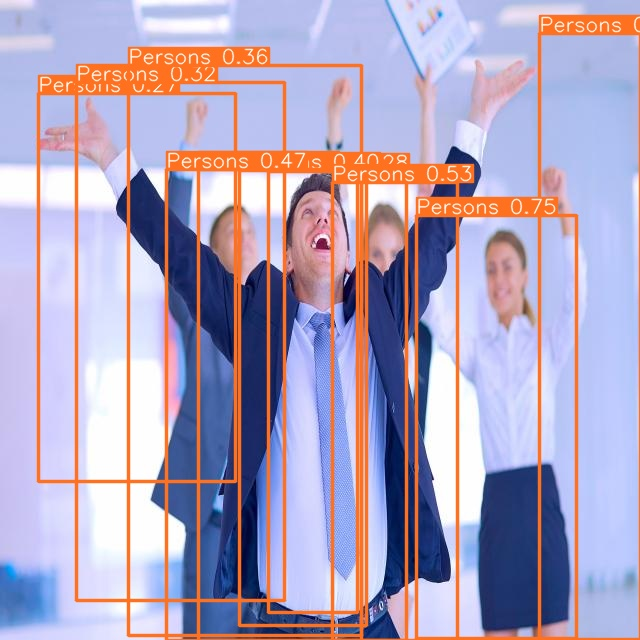

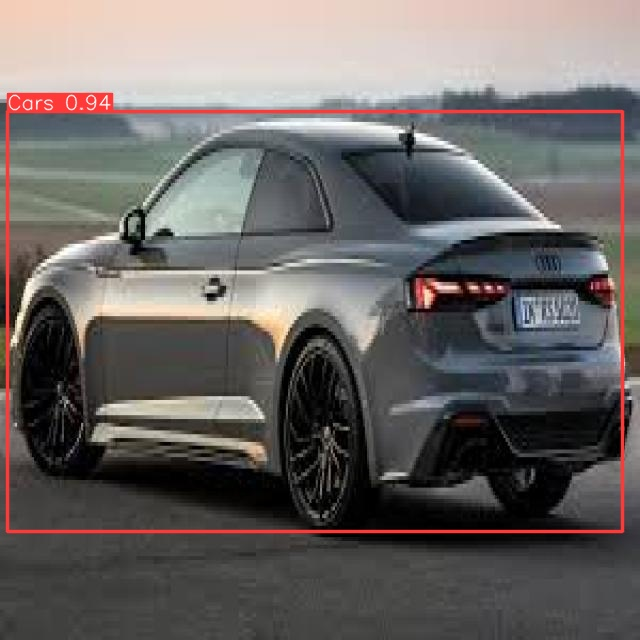

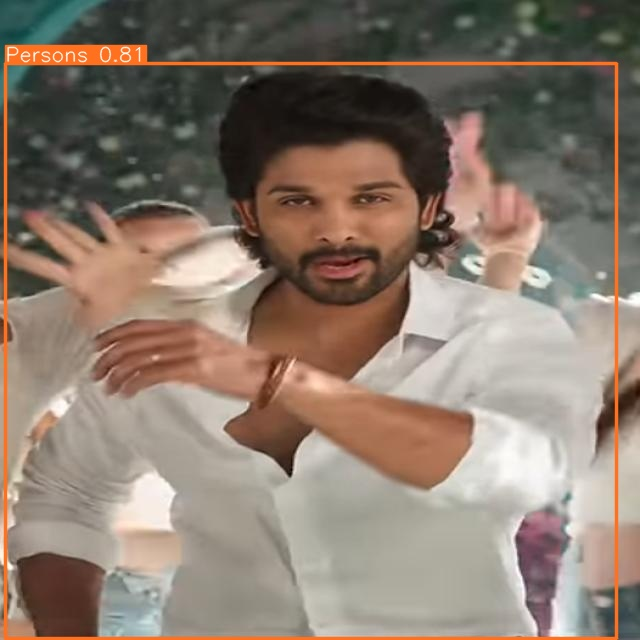

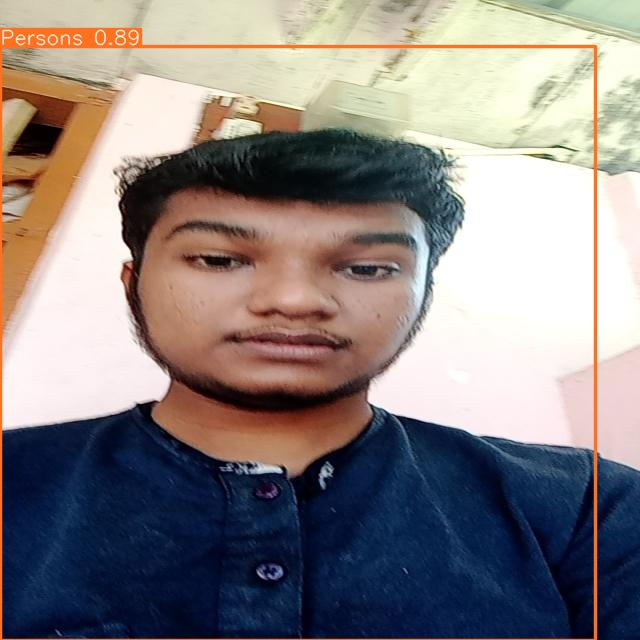

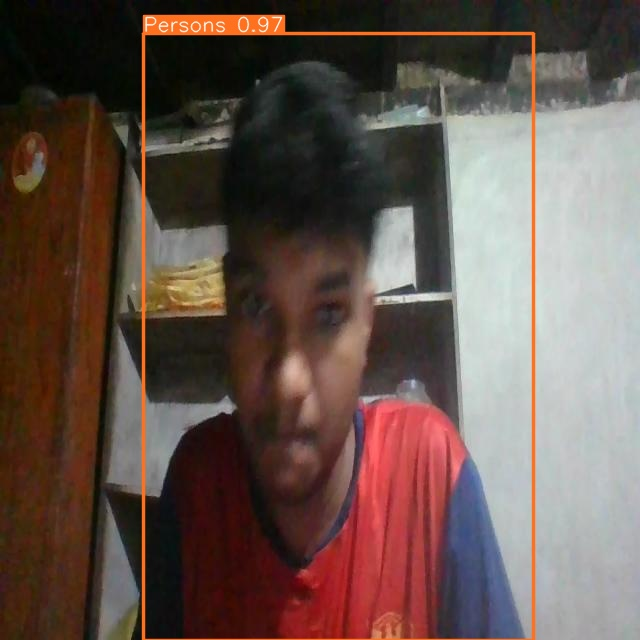

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/runs/detect/predict8/*.jpg')[:25]:
      display(Image(filename=image_path, width=600))
      print("\n")

In [ ]:
project.version(3).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train3/")

An error occured when getting the model upload URL: This version already has a trained model. Please generate and train a new version in order to upload model to Roboflow.


In [ ]:
project.version(2).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train2/")

An error occured when getting the model upload URL: This version already has a trained model. Please generate and train a new version in order to upload model to Roboflow.
